Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.2733 - loss: 2.1210 - val_accuracy: 0.3028 - val_loss: 1.9835
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3082 - loss: 1.9051 - val_accuracy: 0.3494 - val_loss: 1.8399


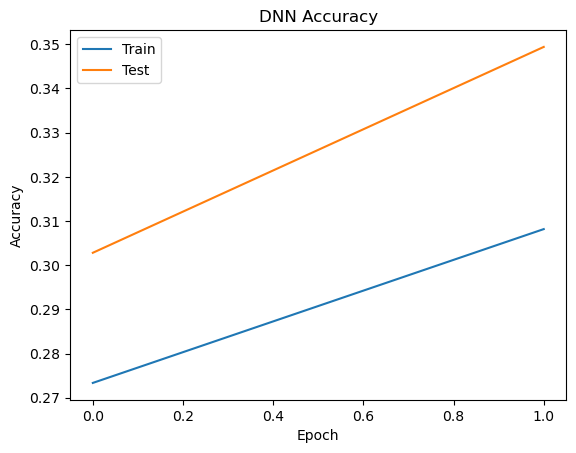

In [3]:
#7
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import cifar10

# Load Data
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

# Normalize
x_train,x_test=x_train/255.0,x_test/255.0

# DNN Model
model=models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),

    layers.Dense(256,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history=model.fit(x_train,y_train,
                  epochs=2,
                  validation_data=(x_test,y_test))

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("DNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Test'])
plt.show()

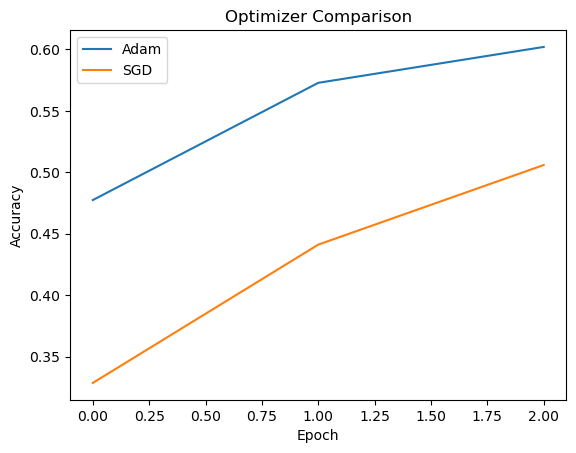

In [4]:
#8
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import cifar10

# Load Data
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

# Normalize
x_train,x_test=x_train/255.0,x_test/255.0

# CNN Function
def create_model():
    model=models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32,(3,3),activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(10,activation='softmax')
    ])
    return model

# Adam
model1=create_model()
model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

h1=model1.fit(x_train,y_train,epochs=3,verbose=0)

# SGD
model2=create_model()
model2.compile(optimizer='sgd',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

h2=model2.fit(x_train,y_train,epochs=3,verbose=0)

# Graph
plt.plot(h1.history['accuracy'])
plt.plot(h2.history['accuracy'])

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Adam", "SGD"])
plt.show()

Using CPU
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 
Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9254 - loss: 0.2465 - val_accuracy: 0.9724 - val_loss: 0.0839
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9759 - loss: 0.0778 - val_accuracy: 0.9801 - val_loss: 0.0556
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Predicted Digit :  7


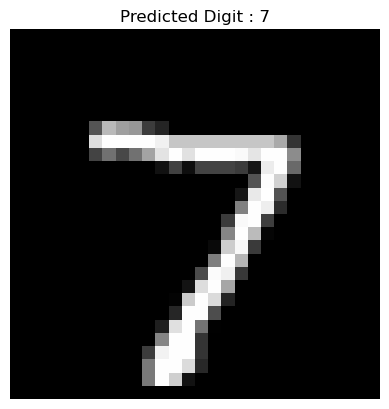

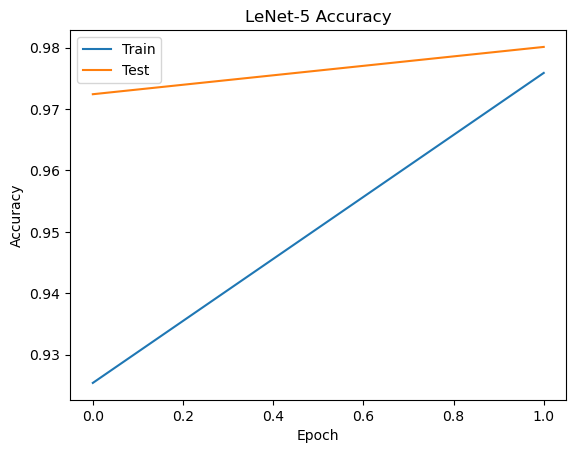

In [5]:
#9

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import mnist

print("Using CPU")

# Load Dataset
(x_train,y_train),(x_test,y_test)=mnist.load_data()

# Normalize
x_train=x_train/255.0
x_test=x_test/255.0

# Reshape
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

# LeNet-5 Model
model=models.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(6,(5,5),activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(16,(5,5),activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),

    layers.Dense(120,activation='relu'),
    layers.Dense(84,activation='relu'),

    layers.Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history=model.fit(
    x_train,
    y_train,
    epochs=2,
    validation_data=(x_test,y_test)
)

# Predict
pred=model.predict(x_test[:1])

print("Predicted Digit : ",pred.argmax())

# Show Image
plt.imshow(x_test[0].reshape(28,28),cmap='gray')
plt.title("Predicted Digit : "+str(pred.argmax()))
plt.axis("off")
plt.show()

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("LeNet-5 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Test'])

plt.show()

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.5022 - loss: 1.3927 - val_accuracy: 0.6097 - val_loss: 1.1428
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6476 - loss: 1.0072 - val_accuracy: 0.6652 - val_loss: 0.9695
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


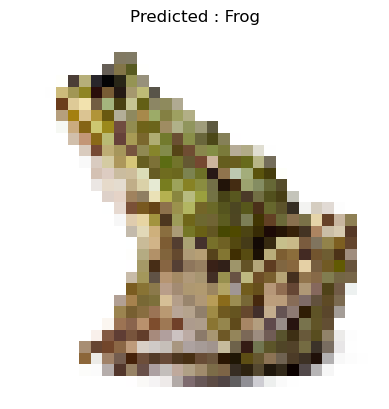

In [1]:
#10
# AlexNet Image Classification using Custom Image

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing import image

# CIFAR10 Class Names
classes = ['Airplane','Automobile','Bird','Cat','Deer',
           'Dog','Frog','Horse','Ship','Truck']

# Load Dataset
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

# Normalize
x_train,x_test=x_train/255.0,x_test/255.0

# AlexNet-Like Model
model=models.Sequential([
    layers.Input(shape=(32,32,3)),
    
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Flatten(),
    
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train Model
history=model.fit(x_train,y_train,
                  epochs=2,
                  validation_data=(x_test,y_test))

# --------- IMAGE CLASSIFICATION ---------

# Load Your Image
img=image.load_img("frog.jpg",target_size=(32,32))

# Convert Image to Array
img_array=image.img_to_array(img)/255.0
img_array=np.expand_dims(img_array,axis=0)

# Predict
prediction=model.predict(img_array)

# Get Class
predicted_class=classes[np.argmax(prediction)]

# Show Image
plt.imshow(img)
plt.title("Predicted : "+predicted_class)
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Predicted Word : powerful


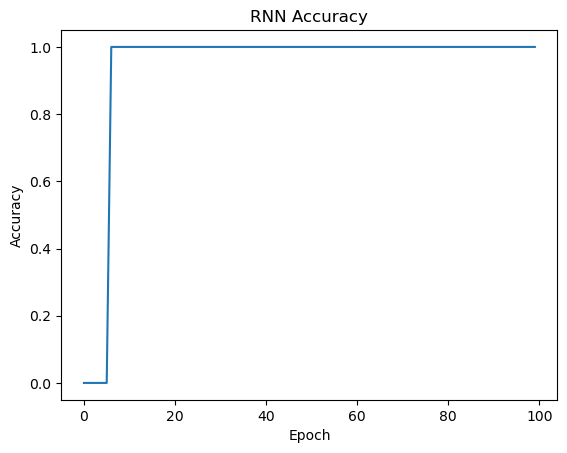

In [3]:
#11 
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

# Text
text=["deep learning is powerful"]

# Tokenize
tok=Tokenizer()
tok.fit_on_texts(text)

seq=tok.texts_to_sequences(text)[0]

X=np.array([seq[:3]])
y=np.array([seq[3]])

# Model
model=Sequential([
    Embedding(20,8,input_length=3),
    SimpleRNN(16),
    Dense(20,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history=model.fit(X,y,epochs=100,verbose=0)

# Predict
pred=np.argmax(model.predict(X),axis=1)

# Display Word
print("Predicted Word :",tok.index_word[pred[0]])

# Graph
plt.plot(history.history['accuracy'])
plt.title("RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

C:\Users\madhu\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Generated Text : artificial intelligence is amazing


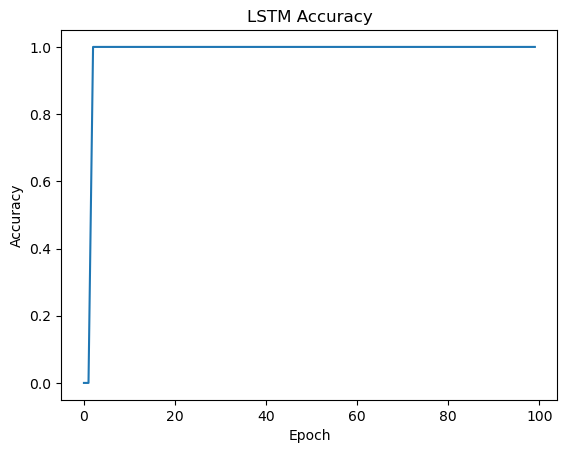

In [5]:
# 12 
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense
from tensorflow.keras.preprocessing.text import Tokenizer

# Text
text=["artificial intelligence is amazing"]

# Tokenizer
tok=Tokenizer()
tok.fit_on_texts(text)

seq=tok.texts_to_sequences(text)[0]

# Input and Output
X=np.array([seq[:3]])
y=np.array([seq[3]])

# Model
model=Sequential([
    Embedding(20,8,input_length=3),
    LSTM(32),
    Dense(20,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history=model.fit(X,y,epochs=100,verbose=0)

# Predict
pred=np.argmax(model.predict(X),axis=1)

# Convert Index to Word
word=tok.index_word[pred[0]]

# Generated Text
input_text="artificial intelligence is"
generated_text=input_text+" "+word

print("Generated Text :",generated_text)

# Graph
plt.plot(history.history['accuracy'])
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()